# Citi Bike Data Analysis 2026

**Note:** Using current data from December 2025 to January 2026 avaliable in the [Official Citi Bike](https://citibikenyc.com/system-data) website.

In [4]:
import pandas as pd
import statistics
import matplotlib.pyplot as plt
import h3
import folium

df_dec = pd.read_csv(r'data\JC-202512.csv')
df_jan = pd.read_csv(r'data\JC-202601.csv')
df_feb = pd.read_csv(r'data\JC-202602.csv')
df_mar = pd.read_csv(r'data\JC-202603.csv')
df_apr = pd.read_csv(r'data\JC-202604.csv')
df_may = pd.read_csv(r'data\JC-202605.csv')
df_june = pd.read_csv(r'data\JC-202606.csv')

# Combine all monthly dataframes into one
df_all = pd.concat([df_dec, df_jan, df_feb, df_mar, df_apr, df_may, df_june], ignore_index=True)

# Save to a single CSV
df_all.to_csv(r'data\combined_rides.csv', index=False)

print(f"Combined shape: {df_all.shape}")
df_all.head()



Combined shape: (464213, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FBA120ADE8D22E7D,electric_bike,2025-12-26 10:20:09.188,2025-12-26 10:40:13.508,Lafayette Park,JC078,Vesey St & Greenwich St,5216.07,40.713464,-74.062859,40.712547,-74.011131,casual
1,DB8F52B8AE51DD28,electric_bike,2025-12-16 06:48:28.111,2025-12-16 06:56:10.969,Dr. Lena Edwards Park,JC117,Exchange Pl,JC116,40.713203,-74.058261,40.716366,-74.034344,member
2,C16D1CA1746E065F,electric_bike,2025-12-20 12:50:55.361,2025-12-20 12:58:32.234,Dr. Lena Edwards Park,JC117,Exchange Pl,JC116,40.713203,-74.058261,40.716366,-74.034344,member
3,7A613AF4BD6D75B9,electric_bike,2025-12-22 16:59:42.922,2025-12-22 17:04:29.327,JC Medical Center,JC110,Exchange Pl,JC116,40.715391,-74.049692,40.716366,-74.034344,casual
4,2448F2B5B85E52B1,electric_bike,2025-12-17 18:06:09.352,2025-12-17 18:14:13.548,Baldwin at Montgomery,JC020,Exchange Pl,JC116,40.723659,-74.064194,40.716366,-74.034344,member


In [5]:
df_all.dtypes

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

### Column Names
**ride_id** - References specific individual bicycle journey  
**rideable_type** - electric or classic  
**started_at** - date & time  
**ended_at** - date & time  
**start_station_name** - could combine with start_station_id  
**start_station_id** - could combine with start_station_name  
**end_station_name** - could combine with end_station_id  
**end_station_id** - could combine with end_station_name  
**start_lat** - lat of starting location  
**start_lng** - lng of starting location  
**end_lat** - lat of ending location  
**end_lng** - lng of ending location  
**member_casual** - casual or member  
&emsp;* casual - pay for a single ride ($4.79 for 30 minutes) or Day Pass ($19 for unlimited 30 minute rides on classic bikes)  
&emsp;* member - pay fee annually ($239 per year) for unlimited 45-minute rides  

In [9]:
dec_count = len(df_dec)
print(dec_count)

jan_count = len(df_jan)
print(jan_count)

feb_count = len(df_feb)
print(feb_count)

mar_count = len(df_mar)
print(mar_count)

apr_count = len(df_apr)
print(apr_count)

may_count = len(df_may)
print(may_count)

june_count = len(df_june)
print(june_count)

counts = [dec_count, jan_count, feb_count, mar_count, apr_count, may_count, jan_count]

# mean
print(statistics.mean(counts))

48474
40044
25809
62367
82272
95350
109897
56337.142857142855


### Total Rides Per Month
**December:** 48474  (below avg)  
**January:** 40044  (below avg)  
**February:** 25809  (below avg)  
**March:** 62367  (below avg)  
**April:** 82272  (above avg)  
**May:** 95350  (above avg)  
**June:** 109897  (above avg)  

### Mean Rides Per Month
66316.14285714286

In [10]:
ride_counts_dec = df_dec['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_dec)

ride_counts_jan = df_jan['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_jan)

ride_counts_feb = df_feb['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_feb)

ride_counts_mar = df_mar['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_mar)

ride_counts_apr = df_apr['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_apr)

ride_counts_may = df_may['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_may)

ride_counts_june = df_june['rideable_type'].value_counts(normalize=True) * 100
print(ride_counts_june)

ride_counts = [ride_counts_dec, ride_counts_jan, ride_counts_feb, ride_counts_mar, ride_counts_apr, ride_counts_may, ride_counts_june]

# mean
# rows = months, columns = type
combined_ride_counts = pd.concat(ride_counts, axis=1).T

print(combined_ride_counts)

mean_ride_counts = combined_ride_counts.mean()
print(mean_ride_counts)


rideable_type
electric_bike    72.017989
classic_bike     27.982011
Name: proportion, dtype: float64
rideable_type
electric_bike    68.666966
classic_bike     31.333034
Name: proportion, dtype: float64
rideable_type
electric_bike    68.092526
classic_bike     31.907474
Name: proportion, dtype: float64
rideable_type
electric_bike    65.23482
classic_bike     34.76518
Name: proportion, dtype: float64
rideable_type
electric_bike    65.001459
classic_bike     34.998541
Name: proportion, dtype: float64
rideable_type
electric_bike    62.65548
classic_bike     37.34452
Name: proportion, dtype: float64
rideable_type
electric_bike    62.470313
classic_bike     37.529687
Name: proportion, dtype: float64
rideable_type  electric_bike  classic_bike
proportion         72.017989     27.982011
proportion         68.666966     31.333034
proportion         68.092526     31.907474
proportion         65.234820     34.765180
proportion         65.001459     34.998541
proportion         62.655480     37.344

### Electric Or Classic

Overall, about 2/3 of Citi Bike users use electric over classic bikes.

**December**  
electric_bike: 72.017989  
classic_bike: 27.982011  

**January**  
electric_bike: 68.666966  
classic_bike: 31.333034  

**February**  
electric_bike: 68.092526  
classic_bike: 31.907474  

**March**  
electric_bike: 65.23482  
classic_bike: 34.76518  

**April**  
electric_bike: 65.001459  
classic_bike: 34.998541  

**May**  
electric_bike: 62.65548  
classic_bike: 37.34452  

**June**  
electric_bike: 62.470313  
classic_bike: 37.529687  

**Mean**  
electric_bike: 66.30565  
classic_bike: 33.69435  

hour
0      5371
1      3155
2      2319
3      1378
4      2031
5      5313
6     13418
7     25549
8     32498
9     20217
10    19290
11    21623
12    23246
13    23428
14    24381
15    29052
16    33760
17    46275
18    42817
19    30672
20    21976
21    16038
22    12008
23     8398
Name: count, dtype: int64


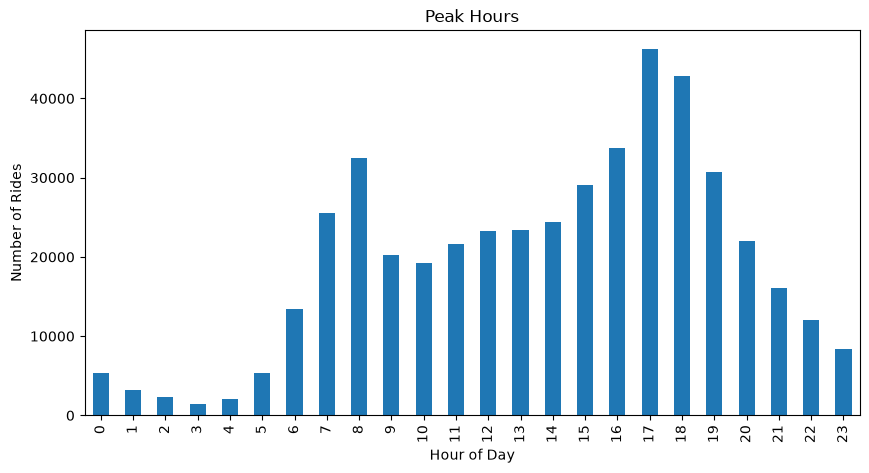

day_of_week
Friday       73081
Tuesday      72074
Wednesday    71810
Thursday     70851
Monday       64015
Saturday     60287
Sunday       52095
Name: count, dtype: int64
day_of_week
Monday       64015
Tuesday      72074
Wednesday    71810
Thursday     70851
Friday       73081
Saturday     60287
Sunday       52095
Name: count, dtype: int64


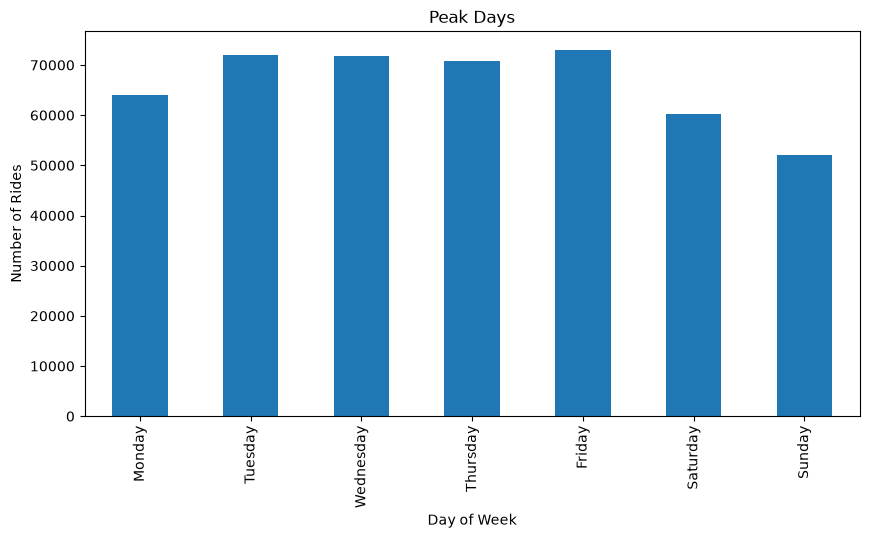

In [12]:
df_all['started_at'] = pd.to_datetime(df_all['started_at'])

df_all['date'] = df_all['started_at'].dt.date
df_all['time'] = df_all['started_at'].dt.time
df_all['hour'] = df_all['started_at'].dt.hour

hourly_counts = df_all['hour'].value_counts().sort_index()
print(hourly_counts)

hourly_counts.plot(kind='bar', figsize=(10,5))
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.title('Peak Hours')
plt.show()

df_all['day_of_week'] = df_all['started_at'].dt.day_name()

day_counts = df_all['day_of_week'].value_counts()
print(day_counts)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_all['day_of_week'].value_counts().reindex(day_order)
print(day_counts)

day_counts.plot(kind='bar', figsize=(10,5))
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.title('Peak Days')
plt.show()

In [ ]:
# drop rows with missing or invalid coordinates
df_all = df_all.dropna(subset=['start_lat', 'start_lng'])

df_all = df_all[
    (df_all['start_lat'].between(-90, 90)) &
    (df_all['start_lng'].between(-180, 180))
]

print(f"Remaining rows: {len(df_all)}")

resolution = 10

# Now run the H3 assignment
df_all['h3_index'] = df_all.apply(
    lambda row: h3.latlng_to_cell(row['start_lat'], row['start_lng'], resolution), 
    axis=1
)

hex_counts = df_all['h3_index'].value_counts().reset_index()
hex_counts.columns = ['h3_index', 'count']

# center map
center_lat = df_all['start_lat'].mean()
center_lng = df_all['start_lng'].mean()

# group by hex, find most common station name
station_per_hex = (
    df_all.groupby('h3_index')['start_station_name']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
station_per_hex.columns = ['h3_index', 'dominant_station']

hex_counts = hex_counts.merge(station_per_hex, on='h3_index', how='left')
print(hex_counts.head())

m = folium.Map(location=[center_lat, center_lng], zoom_start=12, tiles='cartodbpositron')

max_count = hex_counts['count'].max()

for _, row in hex_counts.iterrows():
    boundary = h3.cell_to_boundary(row['h3_index'])
    intensity = row['count'] / max_count
    
    folium.Polygon(
        locations=boundary,
        color=None,
        fill=True,
        fill_color='red',
        fill_opacity=intensity * 0.8,
        tooltip=f"Station: {row['dominant_station']}<br>Rides: {row['count']}"
    ).add_to(m)

m

Remaining rows: 464212
          h3_index  count                          dominant_station
0  8a2a1072e797fff  21557                             Grove St PATH
1  8a2a107216a7fff  16475                      River St & Newark St
2  8a2a10721687fff  12545  Hoboken Terminal - Hudson St & Hudson Pl
3  8a2a10705daffff  11239                      Bergen Ave & Sip Ave
4  8a2a1072e587fff   9953                             Hamilton Park


# Weather Data Analysis 2026

Using [NOAA official weather dataset](https://www.ncdc.noaa.gov/cdo-web/webservices/v2#gettingStarted)
using Central Park's station in NYC.

In [29]:
import requests

token = "zvBPHHgmeRlseXmwqYLCUGIueBnsmjUU"
headers = {"token": token}

response = requests.get(
    "https://www.ncei.noaa.gov/cdo-web/api/v2/data",
    headers=headers,
    params={
        "datasetid": "GHCND",
        "stationid": "GHCND:USW00094728",
        "startdate": "2025-12-01",
        "enddate": "2026-06-30",
        "units": "standard",
        "limit": 1000
    }
)

data = response.json()
df_weather = pd.DataFrame(data['results'])

df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather_pivot = df_weather.pivot(index='date', columns='datatype', values='value')

        date  ride_count  index  AWND  PRCP  SNOW  SNWD  TMAX  TMIN   WDF2  \
0 2025-12-01        2465      0   5.4  0.00   0.0   0.0  43.0  34.0  300.0   
1 2025-12-02        1605      1   5.8  0.78   0.0   0.0  40.0  34.0  300.0   
2 2025-12-03        2398      2   6.3  0.00   0.0   0.0  41.0  31.0  300.0   
3 2025-12-04        2335      3   5.8  0.00   0.0   0.0  41.0  24.0  310.0   
4 2025-12-05        2104      4   5.4  0.00   0.0   0.0  32.0  20.0   60.0   

    WDF5  WSF2  WSF5  WT01  WT02  WT03  WT04  WT06  WT08  WT09  
0  240.0  14.1  25.9   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
1  290.0  15.0  27.1   1.0   NaN   NaN   NaN   NaN   NaN   NaN  
2  300.0  16.1  25.1   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
3  300.0  19.9  33.1   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
4  340.0  12.1  17.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN  


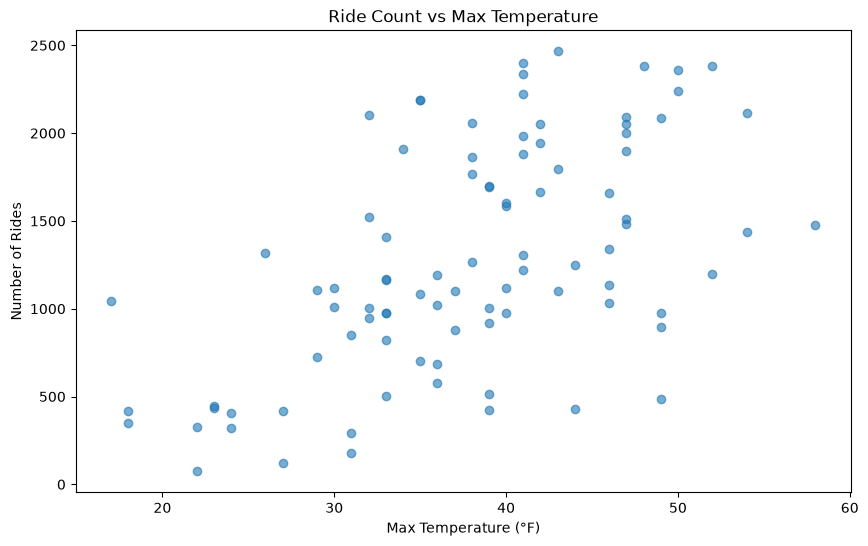

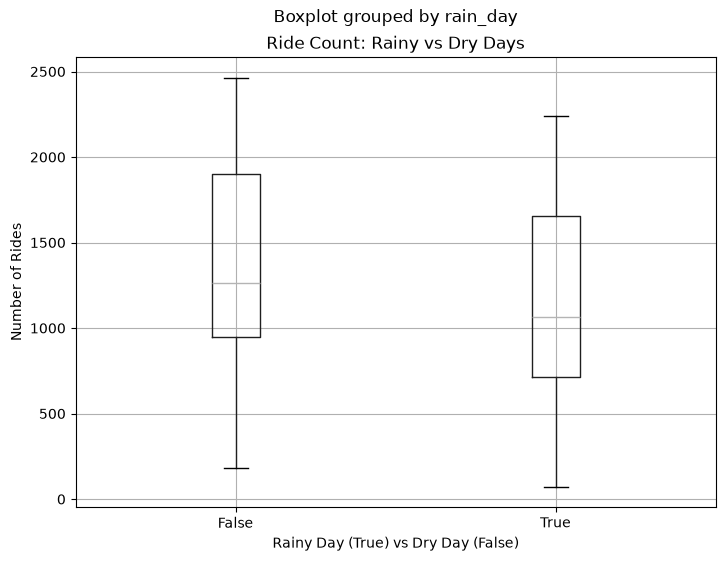

In [31]:
df_all['started_at'] = pd.to_datetime(df_all['started_at'])
df_all['date'] = df_all['started_at'].dt.date

daily_rides = df_all.groupby('date').size().reset_index(name='ride_count')
daily_rides['date'] = pd.to_datetime(daily_rides['date'])

df_weather_pivot = df_weather_pivot.reset_index()
df_weather_pivot['date'] = pd.to_datetime(df_weather_pivot['date'])

merged = pd.merge(daily_rides, df_weather_pivot, on='date', how='inner')
print(merged.head())

plt.figure(figsize=(10,6))
plt.scatter(merged['TMAX'], merged['ride_count'], alpha=0.6)
plt.xlabel('Max Temperature (°F)')
plt.ylabel('Number of Rides')
plt.title('Ride Count vs Max Temperature')
plt.show()

# plot 2: dry v. rainy (boxplot)
merged['rain_day'] = merged['PRCP'] > 0
merged.boxplot(column='ride_count', by='rain_day', figsize=(8,6))
plt.xlabel('Rainy Day (True) vs Dry Day (False)')
plt.ylabel('Number of Rides')
plt.title('Ride Count: Rainy vs Dry Days')
plt.show()

In [25]:
response = requests.get(
    "https://www.ncei.noaa.gov/cdo-web/api/v2/stations/GHCND:USW00094728",
    headers=headers
)

station_info = response.json()
print(station_info)

{'elevation': 42.7, 'mindate': '1869-01-01', 'maxdate': '2026-07-19', 'latitude': 40.77898, 'name': 'NY CITY CENTRAL PARK, NY US', 'datacoverage': 1, 'id': 'GHCND:USW00094728', 'elevationUnit': 'METERS', 'longitude': -73.96925}
